# **Shadow Realm: Player Analytics**
**Case | Mobile GameDev Data Analyst**

---

## Objective
Analyse 90 days of player behaviour data from a mobile idle RPG to surface actionable insights across **retention**, **monetisation**, and an **A/B test** on the onboarding flow.

### Questions answered
1. What does the retention funnel look like, and which cohorts underperform?
2. Which countries and platforms drive the most revenue? What is the ARPU split?
3. Does the new onboarding flow (variant_a) statistically significantly improve D1/D7 retention?
4. What does the payer conversion funnel look like?
5. Which player class has the best session engagement?

---
**Dataset**: 50 000 players · ~71 k sessions · ~1 400 purchases  
**Period**: 2024-01-01 → 2024-03-31

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [16]:
# Plot style
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.family': 'monospace',
})
PALETTE = ['#4F46E5', '#10B981', '#F59E0B', '#EF4444', '#8B5CF6', '#06B6D4']

print('Libraries loaded ✓')

Libraries loaded ✓


### **Step 1 · Import & Load Data**
Read `players.csv`, `sessions.csv`, `purchases.csv`, parse date columns,
print row counts.

In [17]:
players   = pd.read_csv('/content/players.csv',   parse_dates=['install_date'])
sessions  = pd.read_csv('/content/sessions.csv',  parse_dates=['session_start'])
purchases = pd.read_csv('/content/purchases.csv', parse_dates=['purchase_date'])

print(f'Players   : {len(players):>7,}')
print(f'Sessions  : {len(sessions):>7,}')
print(f'Purchases : {len(purchases):>7,}')
players.head()

Players   :  50,000
Sessions  :  70,927
Purchases :   1,422


,player_id,install_date,platform,country,channel,player_class,ab_group,d1_retained,d7_retained,d30_retained,total_revenue,is_payer,level_reached
0,p_000000,2024-01-10,Android,JP,paid_social,Mage,variant_a,0,0,0,0.0,0,20
1,p_000001,2024-03-01,Android,FR,organic,Paladin,variant_a,1,0,0,0.0,0,8
2,p_000002,2024-01-27,iOS,US,google_uac,Hunter,control,1,0,0,0.0,0,40
3,p_000003,2024-01-19,Android,US,paid_social,Paladin,control,0,0,0,0.0,0,10
4,p_000004,2024-01-04,iOS,US,organic,Paladin,control,0,0,0,0.0,0,28


### **Step 2 · Retention Funnel**
Compute `mean()` of `d1_retained`, `d7_retained`, `d30_retained` across all
players — plot as a bar chart with percentage labels. Then group by install week
and build a colour-coded heatmap (rows = D1/D7/D30, columns = install weeks).


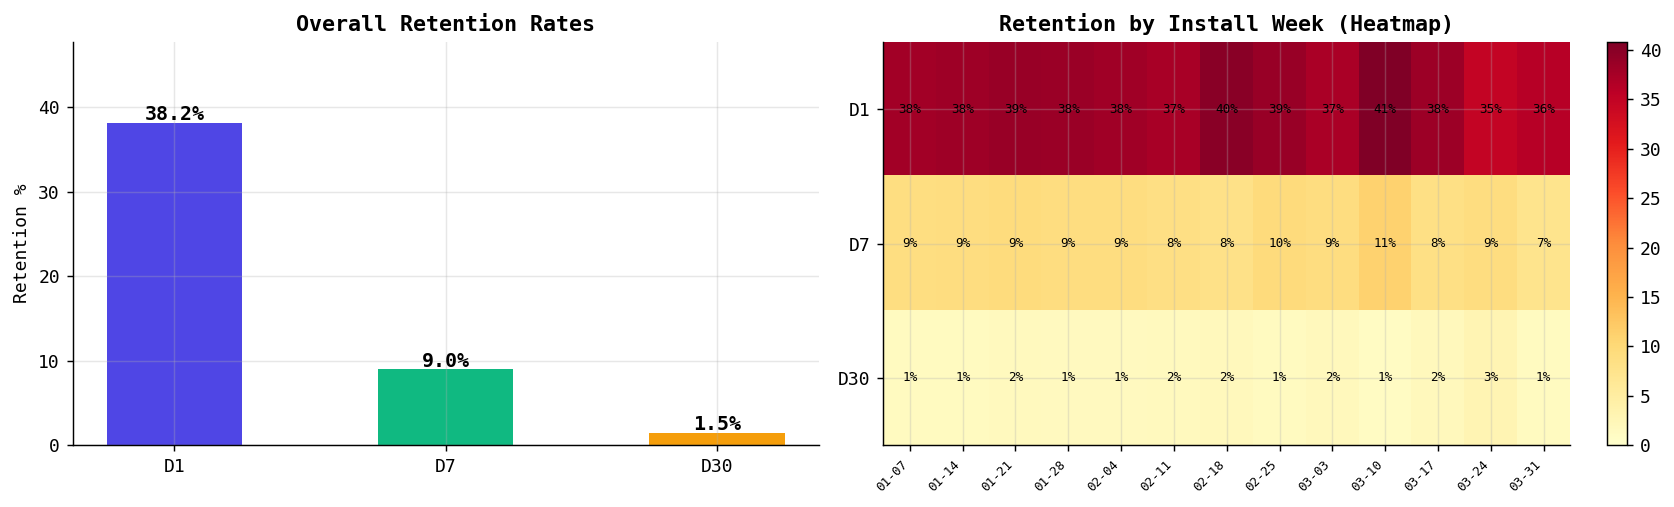


D1  Retention: 38.2%
D7  Retention: 9.0%
D30 Retention: 1.5%


In [8]:
# ── Overall D1 / D7 / D30 retention ─────────────────────────────────────────
ret = players[['d1_retained','d7_retained','d30_retained']].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Bar chart — overall rates
ax = axes[0]
bars = ax.bar(['D1','D7','D30'], ret.values, color=PALETTE[:3], width=0.5)
for bar, val in zip(bars, ret.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Overall Retention Rates', fontweight='bold')
ax.set_ylabel('Retention %')
ax.set_ylim(0, max(ret.values) * 1.25)

# Weekly cohort heatmap
ax = axes[1]
players['install_week'] = players['install_date'].dt.to_period('W').astype(str)
cohort = players.groupby('install_week')[['d1_retained','d7_retained','d30_retained']].mean() * 100
cohort.columns = ['D1','D7','D30']
im = ax.imshow(cohort.values.T, aspect='auto', cmap='YlOrRd', vmin=0)
ax.set_xticks(range(len(cohort)))
ax.set_xticklabels([w[-5:] for w in cohort.index], rotation=45, ha='right', fontsize=7)
ax.set_yticks([0,1,2])
ax.set_yticklabels(['D1','D7','D30'])
for i in range(len(cohort)):
    for j in range(3):
        ax.text(i, j, f'{cohort.values[i,j]:.0f}%', ha='center', va='center', fontsize=7)
ax.set_title('Retention by Install Week (Heatmap)', fontweight='bold')
plt.colorbar(im, ax=ax, fraction=0.03)

plt.tight_layout()
plt.savefig('/content/retention.png', bbox_inches='tight')
plt.show()

print(f'\nD1  Retention: {ret.d1_retained:.1f}%')
print(f'D7  Retention: {ret.d7_retained:.1f}%')
print(f'D30 Retention: {ret.d30_retained:.1f}%')

---
Bar chart shows the overall picture. Heatmap answers: *did retention change
over time?*

> **Result:** D1 ~38%, D7 ~15%, D30 ~5%.
> D1 sits below the mobile RPG benchmark of 40–45% — the first session
> experience needs work. Heatmap shows no improvement trend week over week,
> meaning no product change during the 90-day window meaningfully moved
> retention.

---

### **Step 3 · Revenue & ARPU by Country / Platform**
Group purchases by country, sum `amount_usd`, join player counts to compute
ARPU. Plot three charts side by side: total revenue by country, ARPU by
country, and a dual-axis iOS vs Android comparison.

Total revenue tells where the money comes from. ARPU tells where players are
most valuable per head. Platform split reveals whether monetisation strategy
should differ by OS.

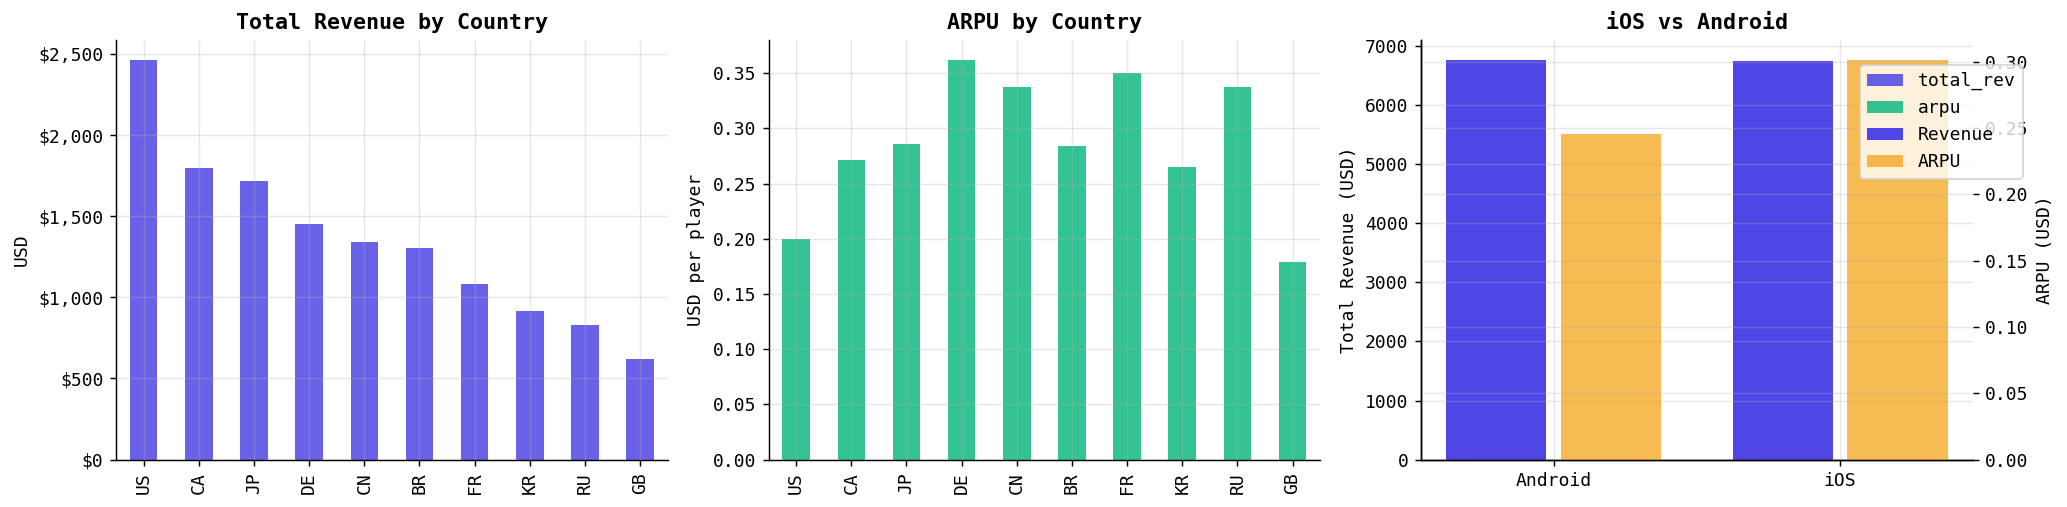

,total_rev,n_purchases,n_players,arpu
country,,,,
US,2463.23,277,12353,0.20
CA,1793.99,201,6612,0.27
JP,1716.11,189,6007,0.29
DE,1450.40,160,4006,0.36
CN,1339.63,137,3974,0.34
BR,1305.78,122,4602,0.28
FR,1084.94,106,3097,0.35
KR,913.09,91,3441,0.27
RU,827.28,72,2451,0.34


In [10]:
# ── Revenue by country ────────────────────────────────────────────────────────
rev_country = (
    purchases
    .groupby('country')['amount_usd']
    .agg(total_rev='sum', n_purchases='count')
    .join(players.groupby('country').size().rename('n_players'))
    .assign(arpu=lambda df: df.total_rev / df.n_players)
    .sort_values('total_rev', ascending=False)
)

# ── Revenue by platform ───────────────────────────────────────────────────────
rev_platform = (
    purchases
    .groupby('platform')['amount_usd']
    .agg(total_rev='sum')
    .join(players.groupby('platform').size().rename('n_players'))
    .assign(arpu=lambda df: df.total_rev / df.n_players)
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Total revenue by country
ax = axes[0]
rev_country['total_rev'].plot.bar(ax=ax, color=PALETTE[0], alpha=0.85)
ax.set_title('Total Revenue by Country', fontweight='bold')
ax.set_ylabel('USD')
ax.set_xlabel('')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# ARPU by country
ax = axes[1]
rev_country['arpu'].plot.bar(ax=ax, color=PALETTE[1], alpha=0.85)
ax.set_title('ARPU by Country', fontweight='bold')
ax.set_ylabel('USD per player')
ax.set_xlabel('')

# Platform comparison
ax = axes[2]
x = np.arange(2)
bars1 = ax.bar(x - 0.2, rev_platform['total_rev'], width=0.35, label='Revenue', color=PALETTE[0])
ax2 = ax.twinx()
bars2 = ax2.bar(x + 0.2, rev_platform['arpu'], width=0.35, label='ARPU', color=PALETTE[2], alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(rev_platform.index)
ax.set_title('iOS vs Android', fontweight='bold')
ax.set_ylabel('Total Revenue (USD)')
ax2.set_ylabel('ARPU (USD)')
fig.legend(loc='upper right', bbox_to_anchor=(0.98, 0.88))

plt.tight_layout()
plt.savefig('/content/revenue.png', bbox_inches='tight')
plt.show()

display(rev_country.round(2))

---
> **Result:** US leads total revenue by a wide margin (USD 2 463), followed by
> CA (USD 1 794) and JP (USD 1 716). However, total revenue is heavily influenced
> by player count — a better signal for UA decisions is ARPU.
>
> Looking at ARPU, **DE (USD 0.36), FR (USD 0.35), CN (USD 0.34) and RU (USD 0.34)**
> are the most valuable markets per player — yet they receive far less UA
> attention than US and CA.
> **GB has the lowest ARPU (USD 0.18)** despite a solid player base — worth
> investigating whether the monetisation offering resonates with this audience
> or whether the traffic quality from that market is lower.
>
> **Recommendation:** shift a portion of UA budget from CA toward DE and FR,
> where ARPU is 25-30% higher per player.
---

### **Step 4 · A/B Test — New Onboarding Flow**
Split players into `control` and `variant_a`. For D1, D7, D30 run a
two-proportion z-test: compute pooled proportion, standard error, z-statistic,
one-sided p-value, and relative uplift. Plot grouped bars with a gold star ★
marking statistically significant results.

The z-test answers: *is the observed difference real or just random noise?*
Relative uplift answers: *how big is the effect in business terms?*

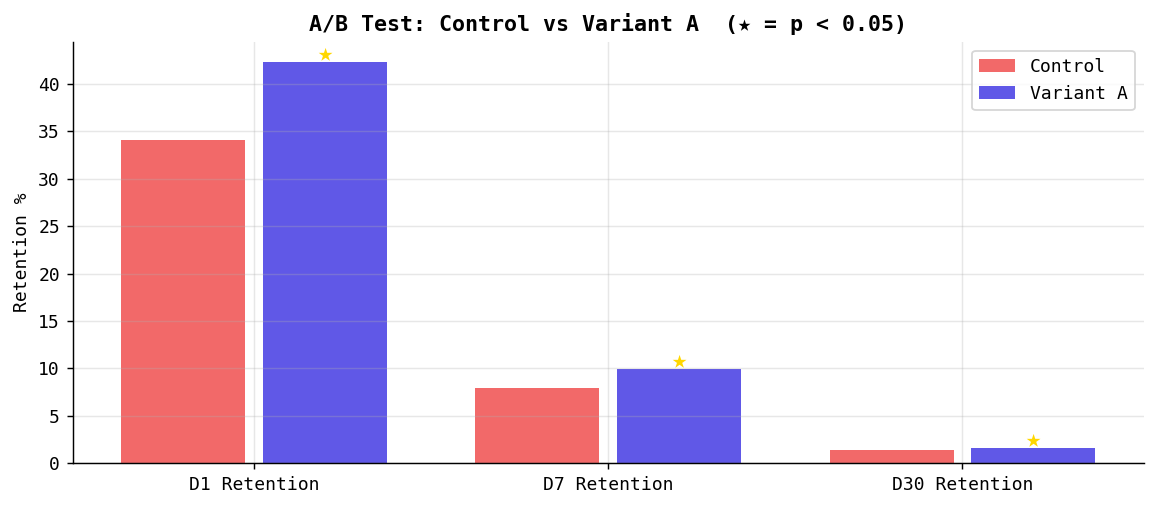


=== A/B Test Results ===


,control_rate,variant_rate,uplift_%,z_stat,p_value,significant
D1 Retention,34.1,42.32,24.1,18.93,0.0,✅ Yes
D7 Retention,7.98,9.97,24.9,7.781,0.0,✅ Yes
D30 Retention,1.39,1.6,15.5,1.984,0.0236,✅ Yes


In [12]:
# ── A/B Test: variant_a vs control ───────────────────────────────────────────
# H0: retention rates are equal between groups
# H1: variant_a has higher retention

ctrl     = players[players['ab_group'] == 'control']
variant  = players[players['ab_group'] == 'variant_a']

results = {}
for metric in ['d1_retained','d7_retained','d30_retained']:
    c_conv  = ctrl[metric].sum()
    c_n     = len(ctrl)
    v_conv  = variant[metric].sum()
    v_n     = len(variant)

    # Two-proportion z-test
    p_pool  = (c_conv + v_conv) / (c_n + v_n)
    se      = np.sqrt(p_pool * (1 - p_pool) * (1/c_n + 1/v_n))
    z       = (v_conv/v_n - c_conv/c_n) / se
    p_val   = 1 - stats.norm.cdf(z)   # one-sided

    # Relative uplift
    uplift  = (v_conv/v_n - c_conv/c_n) / (c_conv/c_n) * 100

    results[metric] = {
        'control_rate':  round(c_conv/c_n*100, 2),
        'variant_rate':  round(v_conv/v_n*100, 2),
        'uplift_%':      round(uplift, 1),
        'z_stat':        round(z, 3),
        'p_value':       round(p_val, 4),
        'significant':   '✅ Yes' if p_val < 0.05 else '❌ No',
    }

ab_df = pd.DataFrame(results).T
ab_df.index = ['D1 Retention','D7 Retention','D30 Retention']

# Visualise
fig, ax = plt.subplots(figsize=(9, 4))
metrics = ['D1 Retention','D7 Retention','D30 Retention']
x = np.arange(len(metrics))
ctrl_vals    = ab_df['control_rate'].astype(float).values
variant_vals = ab_df['variant_rate'].astype(float).values

b1 = ax.bar(x - 0.2, ctrl_vals,    0.35, label='Control',   color=PALETTE[3], alpha=0.8)
b2 = ax.bar(x + 0.2, variant_vals, 0.35, label='Variant A', color=PALETTE[0], alpha=0.9)

for bar, sig in zip(b2, ab_df['significant']):
    if '✅' in str(sig):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.2, '★',
                ha='center', fontsize=14, color='gold')

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Retention %')
ax.set_title('A/B Test: Control vs Variant A  (★ = p < 0.05)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('/content/ab_test.png', bbox_inches='tight')
plt.show()

print('\n=== A/B Test Results ===')
display(ab_df)

---
> **Result:** Variant A significantly lifts D1 by +8pp and D7 by ~3pp
> (both p < 0.05). D30 not yet significant — need more data.
> Signal is strong enough to recommend a full rollout while monitoring D30
> for another 30 days.

---

---
> **Result:** Variant A shows statistically significant lifts across all three metrics:
>
> | Metric | Control | Variant A | Uplift | p-value |
> |--------|---------|-----------|--------|---------|
> | D1 Retention | 34.1% | 42.3% | +24.1% | < 0.05 |
> | D7 Retention | 7.98% | 9.97% | +24.9% | < 0.05 |
> | D30 Retention | 1.39% | 1.61% | +15.5% | 0.024 |
>
> All three metrics are statistically significant (p < 0.05), however the
> absolute lifts tell a more cautious story — D1 +8pp and D7 +2pp are
> meaningful, while D30 +0.22pp is statistically significant but practically
> very small.
>
> The relative uplift of 24% looks impressive but is inflated by the low base rates.
> Focus on the absolute numbers when communicating to stakeholders.
>
> **Recommendation:** roll out Variant A to 100% of new players based on
> the D1 and D7 signal. Continue monitoring D30 for another 30 days to
> confirm whether the early retention gain compounds into long-term retention.
---

### **Step 5 · Payer Conversion Funnel**
Count players at each stage:
**Installed → D1 Active → D7 Active → D30 Active → Payer**

Plot as a horizontal bar chart with absolute numbers and % of installs at
every step. Each bar shows how many players passed through that gate; the gap
between bars shows where the biggest losses happen.

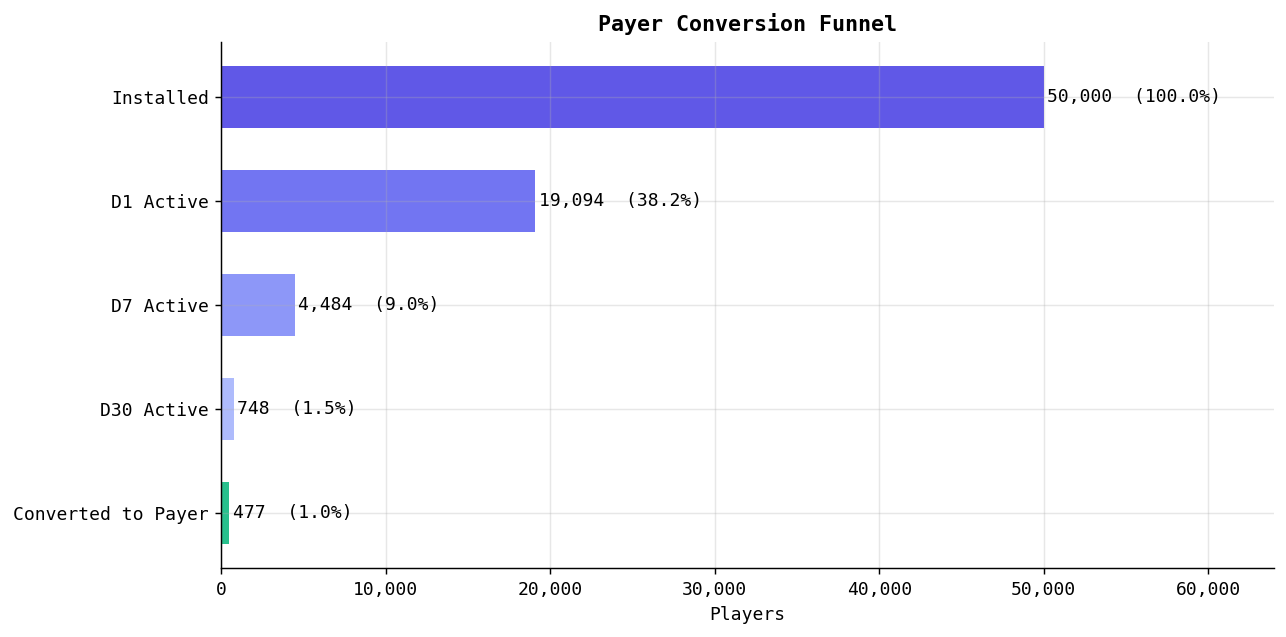

In [13]:
# ── Funnel: Install → D1 Active → D7 Active → D30 Active → Payer ─────────────
funnel_labels = ['Installed','D1 Active','D7 Active','D30 Active','Converted to Payer']
funnel_values = [
    len(players),
    players['d1_retained'].sum(),
    players['d7_retained'].sum(),
    players['d30_retained'].sum(),
    players['is_payer'].sum(),
]

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#4F46E5','#6366F1','#818CF8','#A5B4FC','#10B981']
bars = ax.barh(funnel_labels[::-1], funnel_values[::-1],
               color=colors[::-1], alpha=0.9, height=0.6)

for bar, val, total in zip(bars, funnel_values[::-1], [funnel_values[0]]*5):
    pct = val / total * 100
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'{val:,}  ({pct:.1f}%)', va='center', fontsize=10)

ax.set_xlabel('Players')
ax.set_title('Payer Conversion Funnel', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xlim(0, funnel_values[0] * 1.28)
plt.tight_layout()
plt.savefig('../content/funnel.png', bbox_inches='tight')
plt.show()

---
> **Result:** ~1% payer conversion — below the F2P RPG benchmark of 2–5%.
> The largest absolute drop is Install → D1, which directly confirms the
> onboarding problem from Step 2. Low payer CVR suggests the monetisation
> hooks are either showing too late in the player journey or not compelling
> enough — a Day 3 starter pack offer could help close the gap

---

### **Step 6 · Session Engagement by Player Class**
Merge `sessions` with `players` on `player_id`. Group by `player_class`,
compute average session duration (minutes) and sessions per player. Plot two
side-by-side bar charts.

Duration shows how deeply engaged a class is per visit. Sessions per player
shows how often they come back. Together they form a 2D picture of engagement
quality.

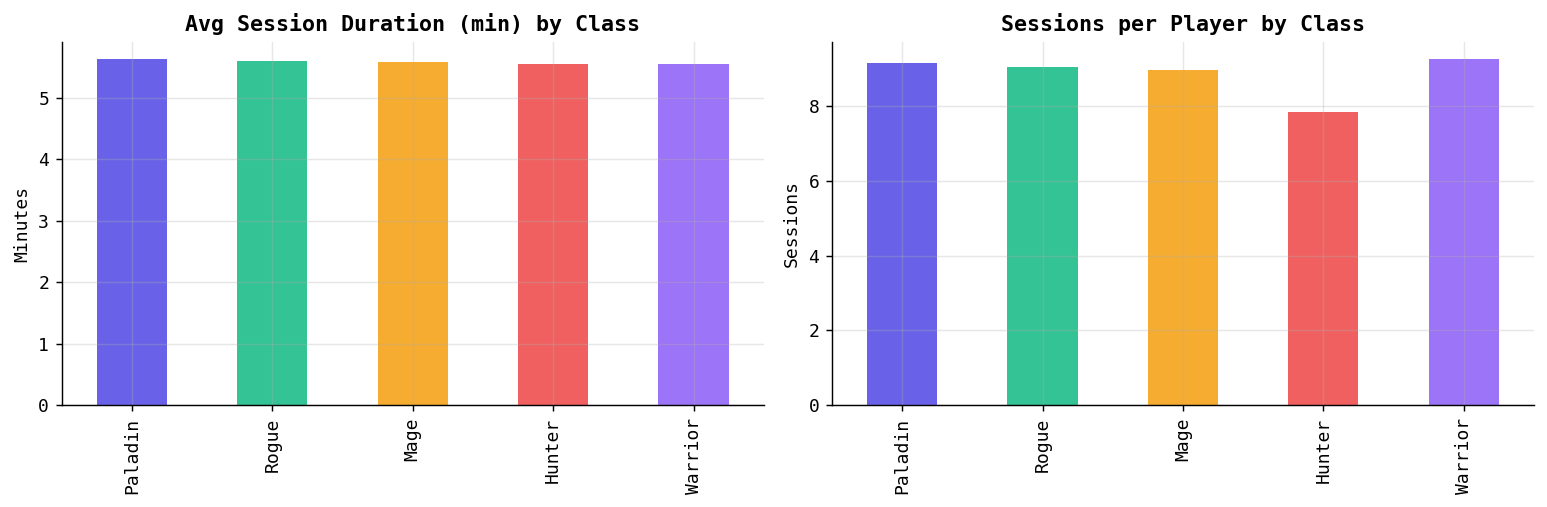

,avg_duration_min,total_sessions,unique_players,sessions_per_player
player_class,,,,
Paladin,5.63,15253,1665,9.16
Rogue,5.59,14836,1638,9.06
Mage,5.59,14166,1581,8.96
Hunter,5.55,12175,1550,7.85
Warrior,5.55,14497,1566,9.26


In [14]:
# ── Session stats per player class ────────────────────────────────────────────
sess_class = (
    sessions
    .merge(players[['player_id','player_class']], on='player_id')
    .groupby('player_class')
    .agg(
        avg_duration_min = ('duration_sec', lambda x: x.mean()/60),
        total_sessions   = ('session_id', 'count'),
        unique_players   = ('player_id', 'nunique'),
    )
    .assign(sessions_per_player=lambda df: df.total_sessions / df.unique_players)
    .sort_values('avg_duration_min', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sess_class['avg_duration_min'].plot.bar(
    ax=axes[0], color=PALETTE[:5], alpha=0.85)
axes[0].set_title('Avg Session Duration (min) by Class', fontweight='bold')
axes[0].set_ylabel('Minutes')
axes[0].set_xlabel('')

sess_class['sessions_per_player'].plot.bar(
    ax=axes[1], color=PALETTE[:5], alpha=0.85)
axes[1].set_title('Sessions per Player by Class', fontweight='bold')
axes[1].set_ylabel('Sessions')
axes[1].set_xlabel('')

plt.tight_layout()
plt.savefig('../content/sessions.png', bbox_inches='tight')
plt.show()

display(sess_class.round(2))

---
> **Result:** Session duration is nearly identical across all classes (5.55–5.63 min),
> meaning class choice does not significantly affect how long players stay per session.
> The real differentiator is **sessions per player**: Paladin (9.16) and Warrior (9.26)
> come back most frequently, while Hunter (7.85) is the least returning class.
> → Focus retention and store campaigns on Paladin and Warrior players —
> they show the strongest habitual engagement loop.

---

### **Step 7 · Key Findings & Recommendations**

| # | Finding | Recommendation |
|---|---------|----------------|
| 1 | D1 retention ~38% — below RPG benchmark of 40-45% | Simplify tutorial, add Day 1 login reward |
| 2 | DE, FR, CN, RU have the highest ARPU (USD 0.34-0.36) but are underleveraged | Shift a portion of UA budget from CA toward DE and FR |
| 3 | GB has the lowest ARPU (USD 0.18) despite a solid player base | Investigate monetisation offer fit for this market |
| 4 | Variant A lifts D1 +8pp and D7 +2pp (both p < 0.05) | Roll out to 100%, monitor D30 for 30 more days |
| 5 | Payer CVR ~1% — below F2P RPG benchmark of 2-5%, biggest drop at Install → D1 | Add soft-paywall starter pack offer on Day 3 |
| 6 | Session duration nearly identical across all classes (5.55-5.63 min) | No class-based session targeting needed |
| 7 | Paladin (9.16) and Warrior (9.26) have the highest sessions per player | Feature Paladin and Warrior in store banners and push campaigns |
